# POMO — Policy Optimization with Multiple Optima
### Implémentation complète en NumPy pur (sans framework deep learning)

Basée sur [Kwon et al., NeurIPS 2020](https://arxiv.org/abs/2010.16011).

---

On implémente **tout à la main** :
- Les couches (`Linear`, `LayerNorm`, `SelfAttention`, …) avec leur propagation avant ET arrière
- L'algorithme REINFORCE avec la baseline POMO
- L'optimiseur Adam

L'objectif est de comprendre exactement ce qui se passe à l'intérieur d'un réseau entraîné par RL.

In [1]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
# ── Chemin du dataset ────────────────────────────────────────────
DATASET_PATH = "../../dataset_raw/chunks/tsp_dataset/tsp_dataset.csv"

# ── Taille du problème ───────────────────────────────────────────
N_CITIES     = 10    # Commencer petit pour NumPy (10 → 20 ensuite)

# ── Architecture ─────────────────────────────────────────────────
D_MODEL      = 64    # Dimension des embeddings
D_FF         = 128   # Dimension FFN dans l'encodeur
N_ENC_LAYERS = 1     # Une seule couche Transformer (suffisant pour débuter)
C            = 10.0  # Clipping tanh dans le décodeur

# ── Entraînement ─────────────────────────────────────────────────
BATCH_SIZE   = 32
N_EPOCHS     = 300
LR           = 1e-3
TEST_RATIO   = 0.2

---
## 1. Chargement du dataset

`tsp_dataset.csv` contient 2 783 instances TSP (20–100 villes).  
On normalise les coordonnées dans $[0, 1]$ et on regroupe par taille.

In [3]:
class TSPDataset:
    """Charge tsp_dataset.csv, normalise dans [0,1], regroupe par num_cities."""

    def __init__(self, csv_path: str, test_ratio: float = 0.2):
        df = pd.read_csv(csv_path)
        df['coords_parsed'] = df['city_coordinates'].apply(ast.literal_eval)

        self.train_buckets: dict = {}
        self.test_buckets:  dict = {}

        for n, group in df.groupby('num_cities'):
            all_coords = np.stack([
                np.array(r, dtype=np.float64) / 100.0
                for r in group['coords_parsed']
            ])  # (K, N, 2)
            K      = len(all_coords)
            n_test = max(1, int(K * test_ratio))
            perm   = np.random.permutation(K)
            self.test_buckets[n]  = all_coords[perm[:n_test]]
            self.train_buckets[n] = all_coords[perm[n_test:]]

        self.sizes = sorted(self.train_buckets.keys())

    def get_batch(self, n_cities: int, batch_size: int, split: str = 'train') -> np.ndarray:
        """Retourne (batch_size, n_cities, 2), avec remplacement si nécessaire."""
        pool = (self.train_buckets if split == 'train' else self.test_buckets)[n_cities]
        idx  = np.random.choice(len(pool), size=batch_size, replace=(batch_size > len(pool)))
        return pool[idx]

    def info(self, n: int | None = None):
        n_tr = sum(len(v) for v in self.train_buckets.values())
        n_te = sum(len(v) for v in self.test_buckets.values())
        print(f"Dataset : {n_tr+n_te} instances  |  train={n_tr}  test={n_te}")
        print(f"Tailles : {min(self.sizes)}–{max(self.sizes)} villes")
        if n:
            print(f"N={n} → train={len(self.train_buckets.get(n,[]))}  "
                  f"test={len(self.test_buckets.get(n,[]))}")


def compute_tour_length(coords: np.ndarray, tour: np.ndarray) -> np.ndarray:
    """
    Longueur euclidienne d'une tournée.
    coords : (B, N, 2)  |  tour : (B, N) int  →  lengths : (B,)
    """
    B, N, _ = coords.shape
    ordered = coords[np.arange(B)[:, None], tour]           # (B, N, 2)
    closed  = np.concatenate([ordered, ordered[:, :1]], 1)  # (B, N+1, 2)
    diffs   = closed[:, 1:] - closed[:, :-1]
    return np.sqrt((diffs**2).sum(-1)).sum(-1)               # (B,)


dataset = TSPDataset(DATASET_PATH, TEST_RATIO)
dataset.info(N_CITIES)

Dataset : 2783 instances  |  train=2254  test=529
Tailles : 20–100 villes
N=10 → train=0  test=0


In [5]:
sample = dataset.get_batch(N_CITIES, 4)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, inst in zip(axes, sample):
    ax.scatter(inst[:, 0], inst[:, 1], c='steelblue', s=70)
    for i, (x, y) in enumerate(inst):
        ax.text(x + 0.01, y + 0.01, str(i), fontsize=8)
    ax.set_title(f"{N_CITIES} villes")
    ax.axis('off')
plt.suptitle("Instances du dataset (coordonnées normalisées)", fontsize=13)
plt.tight_layout()
plt.show()

KeyError: 10

---
## 2. Couches fondamentales (NumPy)

Chaque couche expose :
- `forward(x)` → retourne la sortie **et un cache** (valeurs intermédiaires nécessaires au backward)
- `backward(dout, cache)` → retourne le gradient vers l'entrée, **accumule** les gradients des paramètres
- `zero_grad()` → remet les accumulateurs à zéro
- `params()` → liste de `(paramètre, gradient_accumulé)` pour l'optimiseur

### Pourquoi stocker un cache ?

La rétropropagation a besoin des valeurs du passage avant.  
Exemple pour `y = x @ W` : le gradient de `W` est `x.T @ dy`.  
On doit donc mémoriser `x` au moment du `forward`.  

Dans notre implémentation, le **cache est retourné explicitement** (pas stocké dans `self`) pour éviter
les conflits quand on appelle `forward` plusieurs fois (ex : décodeur appelé N-1 fois par rollout).

In [7]:
class Linear:
    """
    Couche linéaire : y = x @ W + b

    Backward :
        dW = x.T @ dout
        db = dout.sum(axis=0)
        dx = dout @ W.T
    """

    def __init__(self, in_dim: int, out_dim: int):
        # Initialisation de Glorot (réduit les problèmes de gradient explosant/disparaissant)
        scale  = np.sqrt(2.0 / (in_dim + out_dim))
        self.W = np.random.randn(in_dim, out_dim) * scale
        self.b = np.zeros(out_dim)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

    def forward(self, x: np.ndarray):
        """x : (..., in_dim)  →  y : (..., out_dim),  cache : x"""
        return x @ self.W + self.b, x   # (sortie, cache)

    def backward(self, dout: np.ndarray, cache: np.ndarray) -> np.ndarray:
        """
        dout  : (..., out_dim)
        cache : x de ce forward précis
        Accumule dW, db. Retourne dx : (..., in_dim).
        """
        x      = cache
        x_2d   = x.reshape(-1, x.shape[-1])        # (B*..., in_dim)
        dout_2d = dout.reshape(-1, dout.shape[-1])  # (B*..., out_dim)
        self.dW += x_2d.T @ dout_2d
        self.db += dout_2d.sum(axis=0)
        return dout @ self.W.T

    def zero_grad(self):
        self.dW[:] = 0.0
        self.db[:] = 0.0

    def params(self):
        return [(self.W, self.dW), (self.b, self.db)]


class LayerNorm:
    """
    Normalisation de couche : y = gamma * (x - mu) / std + beta

    Backward (formule standard LayerNorm) :
        dx = (1/std) * (dx_n - mean(dx_n) - x_n * mean(dx_n * x_n))
    """

    def __init__(self, d: int, eps: float = 1e-6):
        self.gamma  = np.ones(d)
        self.beta   = np.zeros(d)
        self.eps    = eps
        self.dgamma = np.zeros_like(self.gamma)
        self.dbeta  = np.zeros_like(self.beta)

    def forward(self, x: np.ndarray):
        mu    = x.mean(axis=-1, keepdims=True)
        var   = x.var(axis=-1,  keepdims=True)
        std   = np.sqrt(var + self.eps)
        x_n   = (x - mu) / std
        y     = self.gamma * x_n + self.beta
        cache = (x_n, std)   # tout ce dont backward a besoin
        return y, cache

    def backward(self, dout: np.ndarray, cache) -> np.ndarray:
        x_n, std = cache
        d = dout.shape[-1]
        self.dgamma += (dout * x_n).reshape(-1, d).sum(axis=0)
        self.dbeta  += dout.reshape(-1, d).sum(axis=0)
        dx_n = dout * self.gamma
        dx   = (dx_n
                - dx_n.mean(axis=-1, keepdims=True)
                - x_n * (dx_n * x_n).mean(axis=-1, keepdims=True)
               ) / std
        return dx

    def zero_grad(self):
        self.dgamma[:] = 0.0
        self.dbeta[:]  = 0.0

    def params(self):
        return [(self.gamma, self.dgamma), (self.beta, self.dbeta)]


def relu_forward(x: np.ndarray):
    """ReLU : max(0, x). Cache = masque des activations positives."""
    mask = x > 0
    return x * mask, mask

def relu_backward(dout: np.ndarray, cache) -> np.ndarray:
    """Backward ReLU : gradient nul là où l'entrée était ≤ 0."""
    return dout * cache

---
## 3. Self-Attention et Encodeur Transformer

### Self-Attention (mono-tête)

$$Q = xW_Q,\quad K = xW_K,\quad V = xW_V$$
$$\text{scores} = \frac{QK^\top}{\sqrt{d}}, \quad \alpha = \text{softmax}(\text{scores})$$
$$\text{out} = (\alpha V)\, W_O$$

**Backward** (dérivée de chaque opération en sens inverse) :

| Opération | Gradient |
|---|---|
| $\text{out} = \text{ctx}\, W_O$ | $d\text{ctx} = d\text{out}\, W_O^\top$ |
| $\text{ctx} = \alpha V$ | $d\alpha = d\text{ctx}\, V^\top$, $\;dV = \alpha^\top\, d\text{ctx}$ |
| $\alpha = \text{softmax}(s)$ | $ds = \alpha \odot (d\alpha - \sum_k \alpha_k\, d\alpha_k)$ |
| $s = QK^\top / \sqrt{d}$ | $dQ = ds\, K / \sqrt{d}$, $\;dK = ds^\top Q / \sqrt{d}$ |
| $Q = xW_Q$ | $dx_Q = dQ\, W_Q^\top$, $\;dW_Q = x^\top dQ$ |

In [8]:
class SelfAttention:
    """Self-attention mono-tête avec backward manuel."""

    def __init__(self, d: int):
        self.d   = d
        self.W_Q = Linear(d, d)
        self.W_K = Linear(d, d)
        self.W_V = Linear(d, d)
        self.W_O = Linear(d, d)

    def forward(self, x: np.ndarray):
        """
        x : (B, N, d)  →  out : (B, N, d)
        Cache contient tout ce dont backward a besoin.
        """
        d = self.d

        Q, cQ = self.W_Q.forward(x)  # (B, N, d)
        K, cK = self.W_K.forward(x)
        V, cV = self.W_V.forward(x)

        # Scores d'attention : (B, N, N)
        scores = Q @ K.transpose(0, 2, 1) / np.sqrt(d)

        # Softmax stable (soustraction du max)
        scores -= scores.max(axis=-1, keepdims=True)
        exp_s   = np.exp(scores)
        attn    = exp_s / exp_s.sum(axis=-1, keepdims=True)  # (B, N, N)

        ctx     = attn @ V                      # (B, N, d)
        out, cO = self.W_O.forward(ctx)

        cache = {'x': x, 'Q': Q, 'K': K, 'V': V, 'attn': attn, 'ctx': ctx,
                 'cQ': cQ, 'cK': cK, 'cV': cV, 'cO': cO}
        return out, cache

    def backward(self, dout: np.ndarray, cache: dict) -> np.ndarray:
        """dout : (B, N, d)  →  dx : (B, N, d)"""
        d = self.d
        Q, K, V, attn = cache['Q'], cache['K'], cache['V'], cache['attn']

        # ── Backward W_O ─────────────────────────────────────────────
        dctx = self.W_O.backward(dout, cache['cO'])         # (B, N, d)

        # ── Backward attn @ V ────────────────────────────────────────
        # ctx = attn @ V
        dV    = attn.transpose(0, 2, 1) @ dctx              # (B, N, d)
        dattn = dctx @ V.transpose(0, 2, 1)                 # (B, N, N)

        # ── Backward softmax ─────────────────────────────────────────
        # Pour chaque ligne : ds = a * (da - sum(a*da))
        dscores = attn * (dattn - (attn * dattn).sum(axis=-1, keepdims=True))
        dscores /= np.sqrt(d)   # /sqrt(d) du score

        # ── Backward Q @ K.T ─────────────────────────────────────────
        dQ = dscores @ K                        # (B, N, d)
        dK = dscores.transpose(0, 2, 1) @ Q    # (B, N, d)

        # ── Backward W_Q, W_K, W_V ───────────────────────────────────
        dx_Q = self.W_Q.backward(dQ, cache['cQ'])
        dx_K = self.W_K.backward(dK, cache['cK'])
        dx_V = self.W_V.backward(dV, cache['cV'])

        return dx_Q + dx_K + dx_V   # (B, N, d)

    def zero_grad(self):
        for l in [self.W_Q, self.W_K, self.W_V, self.W_O]:
            l.zero_grad()

    def params(self):
        return (self.W_Q.params() + self.W_K.params() +
                self.W_V.params() + self.W_O.params())


class EncoderLayer:
    """
    Couche Transformer complète : MHA + FFN avec résidus et LayerNorm.

    Forward :
        h1  = x   + Attention(LayerNorm1(x))
        out = h1  + FFN(LayerNorm2(h1))
    """

    def __init__(self, d: int, d_ff: int):
        self.attn  = SelfAttention(d)
        self.norm1 = LayerNorm(d)
        self.norm2 = LayerNorm(d)
        self.ff1   = Linear(d, d_ff)
        self.ff2   = Linear(d_ff, d)

    def forward(self, x: np.ndarray):
        # ── Sous-couche 1 : attention ─────────────────────────────────
        h_n1, cn1 = self.norm1.forward(x)
        h_a,  ca  = self.attn.forward(h_n1)
        h1        = x + h_a                    # connexion résiduelle

        # ── Sous-couche 2 : FFN ───────────────────────────────────────
        h_n2, cn2       = self.norm2.forward(h1)
        h_f1, cf1       = self.ff1.forward(h_n2)
        h_f1r, relu_mask = relu_forward(h_f1)
        h_f2, cf2       = self.ff2.forward(h_f1r)
        out             = h1 + h_f2            # connexion résiduelle

        cache = {'x': x, 'h1': h1,
                 'cn1': cn1, 'ca': ca,
                 'cn2': cn2, 'cf1': cf1, 'relu_mask': relu_mask, 'cf2': cf2}
        return out, cache

    def backward(self, dout: np.ndarray, cache: dict) -> np.ndarray:
        # ── Backward sous-couche 2 ────────────────────────────────────
        dh1_res = dout                                   # résidu 2
        dh_f2   = dout
        dh_f1r  = self.ff2.backward(dh_f2,  cache['cf2'])
        dh_f1   = relu_backward(dh_f1r,     cache['relu_mask'])
        dh_n2   = self.ff1.backward(dh_f1,  cache['cf1'])
        dh1_ffn = self.norm2.backward(dh_n2, cache['cn2'])

        dh1 = dh1_res + dh1_ffn   # gradient total vers h1

        # ── Backward sous-couche 1 ────────────────────────────────────
        dx_res  = dh1                                   # résidu 1
        dh_a    = dh1
        dh_n1   = self.attn.backward(dh_a,  cache['ca'])
        dx_attn = self.norm1.backward(dh_n1, cache['cn1'])

        return dx_res + dx_attn   # (B, N, d)

    def zero_grad(self):
        self.attn.zero_grad()
        self.norm1.zero_grad()
        self.norm2.zero_grad()
        self.ff1.zero_grad()
        self.ff2.zero_grad()

    def params(self):
        return (self.attn.params() + self.norm1.params() + self.norm2.params() +
                self.ff1.params() + self.ff2.params())


class TSPEncoder:
    """Encodeur complet : (B, N, 2) → (B, N, d)."""

    def __init__(self, d: int, d_ff: int, n_layers: int):
        self.proj   = Linear(2, d)
        self.layers = [EncoderLayer(d, d_ff) for _ in range(n_layers)]

    def forward(self, coords: np.ndarray):
        h, c_proj = self.proj.forward(coords)
        layer_caches = []
        for layer in self.layers:
            h, lc = layer.forward(h)
            layer_caches.append(lc)
        return h, (c_proj, layer_caches)

    def backward(self, dh: np.ndarray, cache) -> np.ndarray:
        c_proj, layer_caches = cache
        for layer, lc in zip(reversed(self.layers), reversed(layer_caches)):
            dh = layer.backward(dh, lc)
        return self.proj.backward(dh, c_proj)

    def zero_grad(self):
        self.proj.zero_grad()
        for l in self.layers:
            l.zero_grad()

    def params(self):
        p = self.proj.params()
        for l in self.layers:
            p += l.params()
        return p

---
## 4. Décodeur

À chaque étape $t$, le décodeur calcule :

$$q = [\bar{h} \;\|\; h_{\text{cur}} \;\|\; h_{\text{first}}]\, W_{\text{ctx}}$$
$$K = h_{\text{enc}}\, W_K$$
$$u_j = C \cdot \tanh\!\left(\frac{q \cdot K_j}{\sqrt{d}}\right), \quad u_j = -\infty \text{ si } j \in \text{visités}$$
$$\log p_j = \log\text{softmax}(u)_j$$

**Backward** :
Le gradient REINFORCE alimente seulement la case de l'action choisie :  
$\partial \log p_{a_t} / \partial u_j = \mathbf{1}[j=a_t] - p_j$  
puis on remonte à travers tanh, dot-product, $W_K$ et $W_{\text{ctx}}$.

In [9]:
class TSPDecoder:
    """
    Décodeur par dot-product avec clipping tanh.
    Le forward retourne un cache explicite pour le backward multi-étapes.
    """

    def __init__(self, d: int, C: float = 10.0):
        self.d    = d
        self.C    = C
        self.W_ctx = Linear(3 * d, d)
        self.W_K   = Linear(d, d)

    def forward(
        self,
        h_enc:        np.ndarray,   # (BN, N, d)
        graph_embed:  np.ndarray,   # (BN, d)
        current_embed: np.ndarray,  # (BN, d)
        first_embed:  np.ndarray,   # (BN, d)
        visited_mask: np.ndarray,   # (BN, N) bool
    ):
        BN, N, d = h_enc.shape

        # Construire la requête de contexte
        ctx_in = np.concatenate([graph_embed, current_embed, first_embed], axis=-1)  # (BN, 3d)
        q, c_ctx = self.W_ctx.forward(ctx_in)   # (BN, d)

        # Clés des villes
        K, c_K = self.W_K.forward(h_enc)        # (BN, N, d)

        # Logits : q[b] · K[b,j] / sqrt(d) pour tout j
        # (BN, 1, d) @ (BN, d, N) → (BN, 1, N) → (BN, N)
        logits_raw = (q[:, np.newaxis, :] @ K.transpose(0, 2, 1)).squeeze(1) / np.sqrt(d)
        logits     = self.C * np.tanh(logits_raw)   # (BN, N)

        # Masquer les villes visitées
        logits_m = logits.copy()
        logits_m[visited_mask] = -1e9

        # Log-softmax stable
        logits_m -= logits_m.max(axis=-1, keepdims=True)
        exp_l = np.exp(logits_m)
        exp_l[visited_mask] = 0.0
        probs     = exp_l / (exp_l.sum(axis=-1, keepdims=True) + 1e-9)  # (BN, N)
        log_probs = np.log(probs + 1e-9)                                  # (BN, N)

        cache = {
            'ctx_in': ctx_in, 'c_ctx': c_ctx,
            'h_enc':  h_enc,  'c_K':   c_K,
            'q': q, 'K': K,
            'logits_raw': logits_raw,
            'probs': probs, 'visited_mask': visited_mask,
        }
        return log_probs, probs, cache

    def backward(self, d_log_probs: np.ndarray, cache: dict):
        """
        d_log_probs : (BN, N)  — gradient de la loss vers les log_probs

        Retourne :
            d_h_enc  : (BN, N, d)  — gradient vers les embeddings encodeur
            d_graph  : (BN, d)
            d_current: (BN, d)
            d_first  : (BN, d)
        """
        d = self.d
        probs        = cache['probs']
        visited_mask = cache['visited_mask']
        q, K         = cache['q'], cache['K']

        # ── Backward log_softmax ──────────────────────────────────────
        # d_logits[j] = d_log_p[j] - probs[j] * sum(d_log_p)
        sum_dlp  = d_log_probs.sum(axis=-1, keepdims=True)          # (BN, 1)
        d_logits = d_log_probs - probs * sum_dlp                     # (BN, N)
        d_logits[visited_mask] = 0.0

        # ── Backward tanh clipping ────────────────────────────────────
        # logits = C * tanh(logits_raw)  →  d_raw = d_logits * C * (1 - tanh²)
        d_logits_raw = d_logits * self.C * (1.0 - np.tanh(cache['logits_raw'])**2)

        # ── Backward dot product / sqrt(d) ────────────────────────────
        # logits_raw[b, j] = q[b] · K[b,j] / sqrt(d)
        # d_q[b]    = sum_j d_raw[b,j] * K[b,j] / sqrt(d)
        # d_K[b, j] = d_raw[b,j] * q[b]         / sqrt(d)
        scale    = 1.0 / np.sqrt(d)
        d_q      = (d_logits_raw[:, :, np.newaxis] * K).sum(axis=1) * scale        # (BN, d)
        d_K      = d_logits_raw[:, :, np.newaxis] * q[:, np.newaxis, :] * scale    # (BN, N, d)

        # ── Backward W_K ─────────────────────────────────────────────
        d_h_enc  = self.W_K.backward(d_K, cache['c_K'])    # (BN, N, d)

        # ── Backward W_ctx ────────────────────────────────────────────
        d_ctx_in  = self.W_ctx.backward(d_q, cache['c_ctx'])  # (BN, 3d)
        d_graph   = d_ctx_in[:, :d]
        d_current = d_ctx_in[:, d:2*d]
        d_first   = d_ctx_in[:, 2*d:]

        return d_h_enc, d_graph, d_current, d_first

    def zero_grad(self):
        self.W_ctx.zero_grad()
        self.W_K.zero_grad()

    def params(self):
        return self.W_ctx.params() + self.W_K.params()

---
## 5. Politique POMO

### Forward

1. Encoder les $n$ villes → $H \in \mathbb{R}^{n \times d}$ (une seule fois)
2. Répéter chaque instance $n$ fois (expansion POMO) → $BN$ rollouts
3. Construire $n$ tournées en parallèle, chacune partant d'une ville différente

### Backward

Pour chaque étape de décodage $t$ (en sens inverse) :
- Gradient REINFORCE → `d_log_p` sparse (non-nul uniquement pour l'action choisie)
- Backward décodeur → `d_h_enc`, `d_graph`, `d_current`, `d_first`
- Accumuler dans `d_h_exp` (gradients vers les embeddings de toutes les villes)

Puis sommer `d_h_exp` sur les $n$ copies de chaque instance → `d_h_enc` → backward encodeur.

In [10]:
class PomoPolicy:
    """Politique POMO pour le TSP — implémentation NumPy pur."""

    def __init__(self, d=D_MODEL, d_ff=D_FF, n_enc_layers=N_ENC_LAYERS, C=C):
        self.d       = d
        self.encoder = TSPEncoder(d, d_ff, n_enc_layers)
        self.decoder = TSPDecoder(d, C)

    # ── Forward ──────────────────────────────────────────────────────────

    def forward(self, coords: np.ndarray, greedy: bool = False):
        """
        coords : (B, N, 2)

        Retourne :
            tours        : (B, N, N)
            total_log_p  : (B, N)   — somme des log-probs par rollout
            tour_lengths : (B, N)
        """
        B, N, _ = coords.shape
        BN      = B * N
        idx     = np.arange(BN)

        # ── Encodage (une seule passe pour toute l'instance) ─────────
        h_enc, enc_cache = self.encoder.forward(coords)  # (B, N, d)
        g_enc            = h_enc.mean(axis=1)            # (B, d)

        # ── Expansion POMO ────────────────────────────────────────────
        # Rollout (b, i) = instance b, départ ville i
        h_exp = np.repeat(h_enc, N, axis=0)   # (BN, N, d)
        g_exp = np.repeat(g_enc, N, axis=0)   # (BN, d)

        # Villes de départ : [0,1,...,N-1, 0,1,...,N-1, ...]
        start = np.tile(np.arange(N), B)      # (BN,)

        # ── État initial ──────────────────────────────────────────────
        current      = start.copy()
        visited      = np.zeros((BN, N), dtype=bool)
        visited[idx, start] = True
        first_embed  = h_exp[idx, start]      # (BN, d)

        tours_list = [start.copy()]
        steps      = []  # (log_p, probs, dec_cache, action, current_before)

        # ── Boucle de construction ────────────────────────────────────
        for _ in range(N - 1):
            curr_embed = h_exp[idx, current]   # (BN, d)

            log_p, probs, dec_cache = self.decoder.forward(
                h_exp, g_exp, curr_embed, first_embed, visited.copy()
            )

            if greedy:
                nxt = np.argmax(log_p, axis=-1)
            else:
                # Échantillonnage catégoriel (un tirage par rollout)
                nxt = np.array([
                    np.random.choice(N, p=np.maximum(probs[r], 0) /
                                          np.maximum(probs[r], 0).sum())
                    for r in range(BN)
                ])

            steps.append((log_p, probs, dec_cache, nxt, current.copy()))

            visited[idx, nxt] = True
            current           = nxt
            tours_list.append(nxt.copy())

        # ── Assemblage ────────────────────────────────────────────────
        tours        = np.stack(tours_list, axis=1)   # (BN, N)
        coords_exp   = np.repeat(coords, N, axis=0)
        tour_lengths = compute_tour_length(coords_exp, tours)   # (BN,)

        total_log_p  = np.zeros(BN)
        for log_p, _, _, nxt, _ in steps:
            total_log_p += log_p[idx, nxt]

        # Sauvegarder pour le backward
        self._fwd = {
            'B': B, 'N': N, 'BN': BN,
            'h_enc': h_enc, 'enc_cache': enc_cache,
            'h_exp': h_exp, 'g_exp': g_exp,
            'start': start, 'steps': steps,
        }

        return (tours.reshape(B, N, N),
                total_log_p.reshape(B, N),
                tour_lengths.reshape(B, N))

    # ── Backward ─────────────────────────────────────────────────────────

    def backward(self, advantage: np.ndarray):
        """
        Rétropropagation REINFORCE.
        advantage : (B, N) — avantage par rollout (L_i - mean_L)
        """
        fwd = self._fwd
        B, N, BN, d = fwd['B'], fwd['N'], fwd['BN'], self.d
        idx  = np.arange(BN)

        # Gradient normalisé par le nombre total de rollouts
        adv_flat = (advantage / BN).reshape(BN)   # (BN,)

        # Accumulateur de gradients vers les embeddings étendus
        d_h_exp = np.zeros_like(fwd['h_exp'])     # (BN, N, d)

        # ── Backward à travers chaque étape de décodage (sens inverse) ──
        for log_p, probs, dec_cache, nxt, current_t in reversed(fwd['steps']):

            # Gradient REINFORCE : sparse — uniquement la case de l'action choisie
            # ∂(adv * log p_a)/∂log_p_j = adv * 1[j==a]
            d_log_p = np.zeros_like(log_p)                # (BN, N)
            d_log_p[idx, nxt] = adv_flat

            # Backward décodeur
            d_h_from_K, d_graph, d_current, d_first = self.decoder.backward(
                d_log_p, dec_cache
            )

            # 1. Gradient via W_K (toutes les villes)
            d_h_exp += d_h_from_K

            # 2. Gradient via graph_embed = h_exp.mean(1)  →  uniforme sur N villes
            d_h_exp += d_graph[:, np.newaxis, :] / N

            # 3. Gradient via current_embed = h_exp[idx, current_t]
            np.add.at(d_h_exp, (idx, current_t), d_current)

            # 4. Gradient via first_embed = h_exp[idx, start]
            np.add.at(d_h_exp, (idx, fwd['start']), d_first)

        # ── Réduire d_h_exp → d_h_enc ────────────────────────────────
        # h_exp = repeat(h_enc, N) → sommer les N copies par instance
        # d_h_exp : (BN, N, d)  =  (B, N, N, d)  →  sum sur axis=1  →  (B, N, d)
        d_h_enc = d_h_exp.reshape(B, N, N, d).sum(axis=1)   # (B, N, d)

        # ── Backward encodeur ────────────────────────────────────────
        self.encoder.backward(d_h_enc, fwd['enc_cache'])

    # ── Utilitaires ───────────────────────────────────────────────────────

    def zero_grad(self):
        self.encoder.zero_grad()
        self.decoder.zero_grad()

    def params(self):
        return self.encoder.params() + self.decoder.params()

    def n_params(self) -> int:
        return sum(p.size for p, _ in self.params())

---
## 6. Optimiseur Adam

Adam maintient deux moments exponentiellement lissés du gradient :

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)\, g_t \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2)\, g_t^2$$

Puis corrige le biais et met à jour :

$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t},
\qquad \theta \leftarrow \theta - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \varepsilon}$$

In [11]:
class Adam:
    """Optimiseur Adam pour une liste de paramètres (W, dW)."""

    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = params  # liste de (W, dW)
        self.lr     = lr
        self.beta1, self.beta2, self.eps = beta1, beta2, eps
        self.m = [np.zeros_like(p) for p, _ in params]
        self.v = [np.zeros_like(p) for p, _ in params]
        self.t = 0

    def step(self):
        self.t += 1
        for i, (p, dp) in enumerate(self.params):
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * dp
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * dp ** 2
            m_hat     = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat     = self.v[i] / (1 - self.beta2 ** self.t)
            p        -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

---
## 7. Entraînement REINFORCE

```
Pour chaque epoch :
  1. Échantillonner B instances du dataset
  2. Forward POMO  →  N rollouts × B instances
  3. Baseline     =  longueur moyenne des N rollouts par instance
  4. Avantage     =  L_i - baseline
  5. Backward     →  accumule les gradients
  6. Adam.step()  →  met à jour les paramètres
  7. zero_grad()  →  remet les accumulateurs à zéro
```

In [12]:
def train_pomo(
    model:      PomoPolicy,
    dataset:    TSPDataset,
    n_epochs:   int   = N_EPOCHS,
    batch_size: int   = BATCH_SIZE,
    n_cities:   int   = N_CITIES,
    lr:         float = LR,
):
    optimizer = Adam(model.params(), lr=lr)
    history   = {'loss': [], 'best_tour': [], 'mean_tour': []}

    for epoch in range(1, n_epochs + 1):

        # 1. Données
        coords = dataset.get_batch(n_cities, batch_size, split='train')  # (B, N, 2)

        # 2. Forward POMO
        _, log_probs, tour_lengths = model.forward(coords, greedy=False)
        # log_probs    : (B, N)
        # tour_lengths : (B, N)

        # 3. Baseline POMO = moyenne des N longueurs par instance
        baseline  = tour_lengths.mean(axis=1, keepdims=True)  # (B, 1)
        advantage = tour_lengths - baseline                    # (B, N)

        # 4. Loss REINFORCE (pour le log uniquement, le backward utilise l'avantage)
        loss = (advantage * log_probs).mean()

        # 5. Backward
        model.backward(advantage)

        # 6. Mise à jour + remise à zéro des gradients
        optimizer.step()
        model.zero_grad()

        best   = tour_lengths.min(axis=1).mean()
        mean_t = tour_lengths.mean()
        history['loss'].append(float(loss))
        history['best_tour'].append(float(best))
        history['mean_tour'].append(float(mean_t))

        if epoch % 50 == 0:
            print(f"Epoch {epoch:4d}/{n_epochs} | "
                  f"Loss {loss:+.4f} | "
                  f"Best {best:.4f} | "
                  f"Mean {mean_t:.4f}")

    return history

In [13]:
model = PomoPolicy()
print(f"Paramètres : {model.n_params():,}")
print(f"Entraînement : {N_EPOCHS} epochs · batch={BATCH_SIZE} · N={N_CITIES} villes\n")

history = train_pomo(model, dataset)

Paramètres : 50,176
Entraînement : 300 epochs · batch=32 · N=10 villes



KeyError: 10

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history['loss'], color='tomato', lw=1.5)
ax1.set_title("Loss REINFORCE")
ax1.set_xlabel("Epoch")
ax1.grid(alpha=0.3)

ax2.plot(history['best_tour'], label='Meilleure (POMO)', color='steelblue', lw=1.5)
ax2.plot(history['mean_tour'], label='Moyenne',          color='orange',    lw=1.5, ls='--')
ax2.set_title("Longueur des tournées")
ax2.set_xlabel("Epoch")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. Évaluation sur le split test

Comparaison avec le **Nearest Neighbor (NN)** : heuristique gloutonne qui choisit
à chaque étape la ville non visitée la plus proche.

$$\text{gap} = \frac{L_{\text{POMO}} - L_{\text{NN}}}{L_{\text{NN}}} \times 100\%$$

In [14]:
def nearest_neighbor(coords: np.ndarray):
    """coords : (B, N, 2)  →  tours : (B, N),  lengths : (B,)"""
    B, N, _ = coords.shape
    tours   = np.zeros((B, N), dtype=int)
    lengths = np.zeros(B)
    for b in range(B):
        c       = coords[b]
        visited = np.zeros(N, dtype=bool)
        cur = 0
        visited[cur] = True
        tours[b, 0]  = cur
        length = 0.0
        for step in range(1, N):
            dist          = np.linalg.norm(c - c[cur], axis=-1)
            dist[visited] = np.inf
            nxt           = dist.argmin()
            length       += dist[nxt]
            visited[nxt]   = True
            tours[b, step] = nxt
            cur            = nxt
        length    += np.linalg.norm(c[cur] - c[tours[b, 0]])
        lengths[b] = length
    return tours, lengths

In [15]:
test_coords = dataset.get_batch(N_CITIES, batch_size=50, split='test')  # (50, N, 2)
N_TEST      = len(test_coords)

# POMO greedy
tours_pomo, _, lengths_pomo = model.forward(test_coords, greedy=True)
best_idx     = lengths_pomo.argmin(axis=1)                       # (B,)
best_tours   = tours_pomo[np.arange(N_TEST), best_idx]           # (B, N)
best_lengths = lengths_pomo.min(axis=1)                          # (B,)

# Nearest Neighbor
nn_tours, nn_lengths = nearest_neighbor(test_coords)

pomo_mean = best_lengths.mean()
nn_mean   = nn_lengths.mean()
gap       = (pomo_mean - nn_mean) / nn_mean * 100

print("=" * 55)
print(f"  Instances de test           : {N_TEST}")
print(f"  Longueur moyenne POMO       : {pomo_mean:.4f}")
print(f"  Longueur moyenne NN         : {nn_mean:.4f}")
print(f"  Gap POMO vs NN              : {gap:+.2f}%")
print("  (négatif = POMO fait mieux que NN)")
print("=" * 55)

KeyError: 10

NameError: name 'test_coords' is not defined

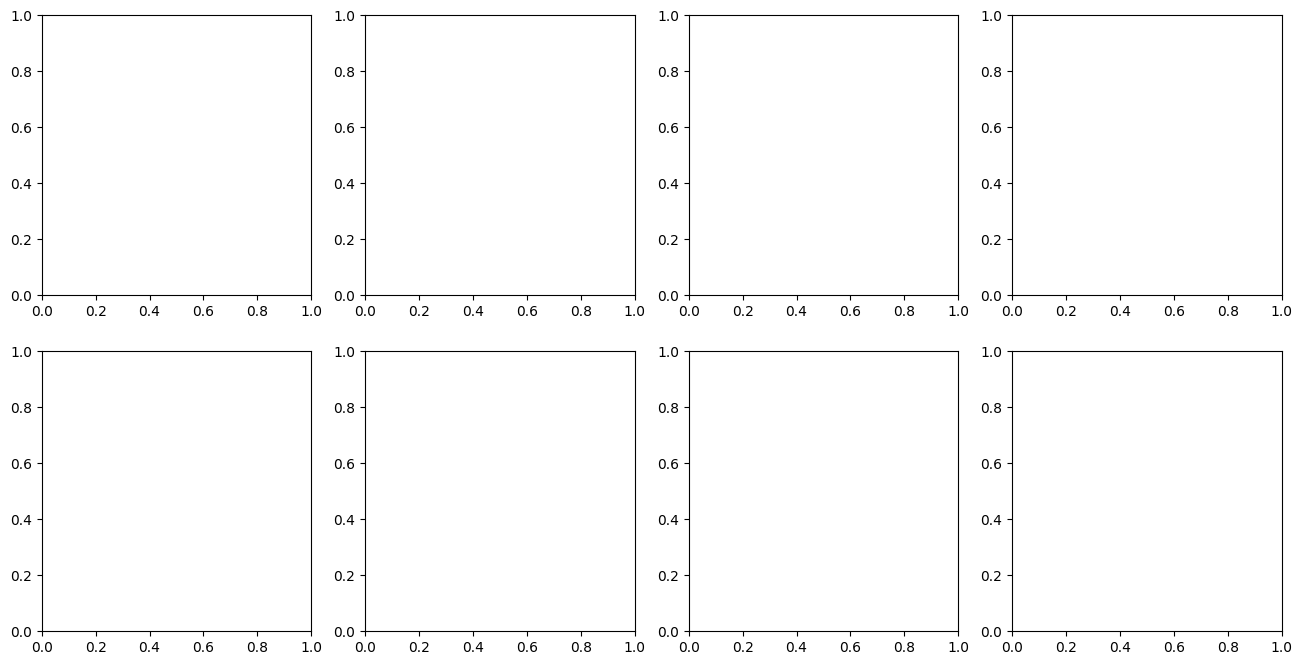

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col in range(4):
    coord = test_coords[col]
    N     = len(coord)

    def draw(ax, tour, color, label, length):
        ax.scatter(coord[:, 0], coord[:, 1], c='steelblue', s=70, zorder=3)
        ax.scatter(coord[tour[0], 0], coord[tour[0], 1],
                   c=color, s=130, zorder=4, marker='*')
        for i in range(N):
            a, b = tour[i], tour[(i + 1) % N]
            ax.plot([coord[a, 0], coord[b, 0]],
                    [coord[a, 1], coord[b, 1]], 'gray', lw=1, alpha=0.8)
        ax.set_title(f"{label}  L={length:.3f}")
        ax.axis('off')

    draw(axes[0, col], best_tours[col], 'red',    'POMO', best_lengths[col])
    draw(axes[1, col], nn_tours[col],   'orange', 'NN',   nn_lengths[col])

axes[0, 0].set_ylabel("POMO", fontsize=12)
axes[1, 0].set_ylabel("Nearest Neighbor", fontsize=12)
plt.suptitle(f"POMO vs Nearest Neighbor — {N_CITIES} villes (test)", fontsize=14)
plt.tight_layout()
plt.show()